In [1]:
import json
import os
from pathlib import Path

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\19012\anaconda3\envs\yelp_nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
def find_project_root(start_dir: Path) -> Path:
    required = Path("data") / "processed" / "train_data.csv"
    current = start_dir.resolve()

    for _ in range(10):
        if (current / required).exists():
            return current
        if current.parent == current:
            break
        current = current.parent

    raise FileNotFoundError(
        "Could not locate project root containing data/processed/train_data.csv. "
        "Please run this notebook from within the project directory."
    )

project_root = find_project_root(Path.cwd())

train_path = project_root / "data" / "processed" / "train_data.csv"
val_path = project_root / "data" / "processed" / "val_data.csv"
test_path = project_root / "data" / "processed" / "test_data.csv"

model_dir = project_root / "s1_baseline_models" / "baseline_bert"
result_dir = project_root / "s1_baseline_results" / "baseline_bert"
checkpoint_dir = model_dir / "checkpoints"
best_model_dir = model_dir / "best_model"
logging_dir = result_dir / "logs"

checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_model_dir.mkdir(parents=True, exist_ok=True)
result_dir.mkdir(parents=True, exist_ok=True)
logging_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Train path:", train_path)
print("Val path:", val_path)
print("Test path:", test_path)
print("Checkpoint dir:", checkpoint_dir)
print("Best model dir:", best_model_dir)
print("Result dir:", result_dir)

Project root: D:\CSE4601_Text Mining\Yelp_Project
Train path: D:\CSE4601_Text Mining\Yelp_Project\data\processed\train_data.csv
Val path: D:\CSE4601_Text Mining\Yelp_Project\data\processed\val_data.csv
Test path: D:\CSE4601_Text Mining\Yelp_Project\data\processed\test_data.csv
Checkpoint dir: D:\CSE4601_Text Mining\Yelp_Project\s1_baseline_models\baseline_bert\checkpoints
Best model dir: D:\CSE4601_Text Mining\Yelp_Project\s1_baseline_models\baseline_bert\best_model
Result dir: D:\CSE4601_Text Mining\Yelp_Project\s1_baseline_results\baseline_bert


In [4]:
print("Loading datasets ...")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

train_df["text"] = train_df["text"].fillna("").astype(str)
val_df["text"] = val_df["text"].fillna("").astype(str)
test_df["text"] = test_df["text"].fillna("").astype(str)

print(f"Train rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")
print("Columns:", list(train_df.columns))

Loading datasets ...
Train rows: 39750
Val rows:   5025
Test rows:  5221
Columns: ['review_id', 'business_id', 'stars', 'text', 'token_count']


In [5]:
train_df["label"] = train_df["stars"].astype(int) - 1
val_df["label"] = val_df["stars"].astype(int) - 1
test_df["label"] = test_df["stars"].astype(int) - 1

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
val_dataset = Dataset.from_pandas(val_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

print("Label value counts (train):")
print(train_df["label"].value_counts().sort_index())

Label value counts (train):
label
0    7853
1    7971
2    7879
3    8000
4    8047
Name: count, dtype: int64


In [6]:
model_name = "distilbert-base-uncased"
num_labels = 5

print(f"Loading tokenizer and model: {model_name} ...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

print("Model loaded.")

Loading tokenizer and model: distilbert-base-uncased ...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 834.77it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


In [7]:
max_length = 128

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

print("Tokenizing datasets ...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

print("Tokenization completed.")
print(tokenized_train)

Tokenizing datasets ...


Map: 100%|██████████| 5221/5221 [00:00<00:00, 10286.89 examples/s]

Tokenization completed.
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 39750
})


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}


def save_confusion_matrix_plot(cm, labels, title, save_path):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def evaluate_and_save(split_name, prediction_output, output_dir, target_names):
    logits = prediction_output.predictions
    true_labels = prediction_output.label_ids
    pred_labels = np.argmax(logits, axis=-1)

    acc = accuracy_score(true_labels, pred_labels)
    macro_f1 = f1_score(true_labels, pred_labels, average="macro")
    report_dict = classification_report(true_labels, pred_labels, target_names=target_names, output_dict=True)
    report_text = classification_report(true_labels, pred_labels, target_names=target_names)
    cm = confusion_matrix(true_labels, pred_labels)

    metrics = {
        "split": split_name,
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "num_samples": int(len(true_labels)),
    }

    with open(output_dir / f"{split_name}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    pd.DataFrame([metrics]).to_csv(output_dir / f"{split_name}_metrics.csv", index=False)
    pd.DataFrame(report_dict).transpose().to_csv(output_dir / f"{split_name}_classification_report.csv")
    pd.DataFrame(cm, index=target_names, columns=target_names).to_csv(output_dir / f"{split_name}_confusion_matrix.csv")
    pd.DataFrame(
        {
            "true_label_index": true_labels,
            "pred_label_index": pred_labels,
            "true_star": true_labels + 1,
            "pred_star": pred_labels + 1,
        }
    ).to_csv(output_dir / f"{split_name}_predictions.csv", index=False)

    with open(output_dir / f"{split_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report_text)

    save_confusion_matrix_plot(
        cm,
        target_names,
        title=f"Confusion Matrix: Fine-tuned BERT ({split_name})",
        save_path=output_dir / f"{split_name}_confusion_matrix.png",
    )

    print(f"--- {split_name.upper()} Performance ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print("\n--- Classification Report ---")
    print(report_text)
    print("--- Confusion Matrix ---")
    print(cm)

    return metrics

In [9]:
training_args = TrainingArguments(
    output_dir=str(checkpoint_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir=str(logging_dir),
    logging_steps=100,
    report_to="none",
)

print("TrainingArguments configured.")
print("Checkpoint dir:", checkpoint_dir)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments configured.
Checkpoint dir: D:\CSE4601_Text Mining\Yelp_Project\s1_baseline_models\baseline_bert\checkpoints


In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("Starting end-to-end fine-tuning ...")
train_result = trainer.train()
print("Training finished.")

Starting end-to-end fine-tuning ...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.878121,0.906929,0.609154,0.604926
2,0.746449,0.957063,0.611741,0.607168
3,0.581860,1.225694,0.619104,0.619625


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.44it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training finished.


In [11]:
trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))

train_metrics = train_result.metrics
with open(result_dir / "train_metrics.json", "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, indent=2)

pd.DataFrame([train_metrics]).to_csv(result_dir / "train_metrics.csv", index=False)

if trainer.state.log_history:
    pd.DataFrame(trainer.state.log_history).to_csv(result_dir / "trainer_log_history.csv", index=False)

print("Best model and training logs saved.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.24it/s]

Best model and training logs saved.


Running final evaluation on the validation set ...


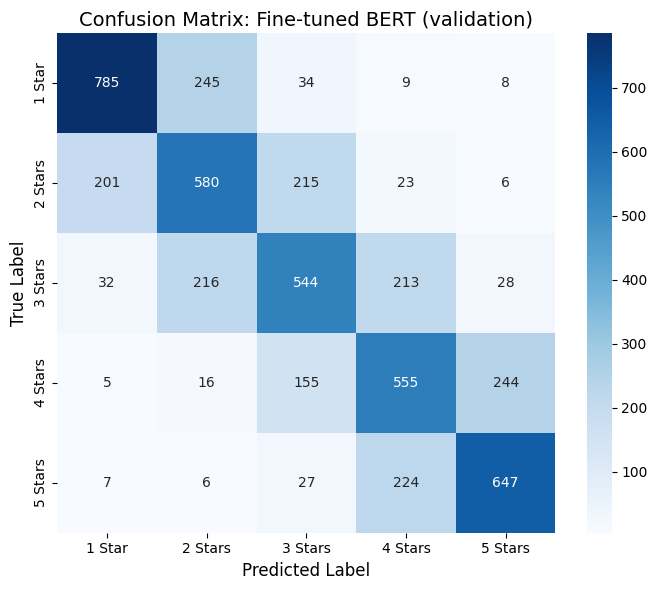

--- VALIDATION Performance ---
Accuracy: 0.6191
Macro-F1: 0.6196

--- Classification Report ---
              precision    recall  f1-score   support

      1 Star       0.76      0.73      0.74      1081
     2 Stars       0.55      0.57      0.56      1025
     3 Stars       0.56      0.53      0.54      1033
     4 Stars       0.54      0.57      0.56       975
     5 Stars       0.69      0.71      0.70       911

    accuracy                           0.62      5025
   macro avg       0.62      0.62      0.62      5025
weighted avg       0.62      0.62      0.62      5025

--- Confusion Matrix ---
[[785 245  34   9   8]
 [201 580 215  23   6]
 [ 32 216 544 213  28]
 [  5  16 155 555 244]
 [  7   6  27 224 647]]

Running final evaluation on the test set ...


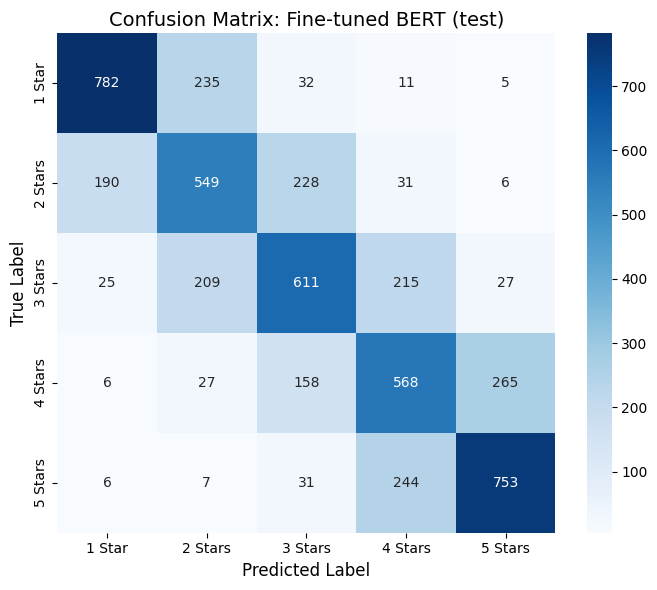

--- TEST Performance ---
Accuracy: 0.6250
Macro-F1: 0.6250

--- Classification Report ---
              precision    recall  f1-score   support

      1 Star       0.78      0.73      0.75      1065
     2 Stars       0.53      0.55      0.54      1004
     3 Stars       0.58      0.56      0.57      1087
     4 Stars       0.53      0.55      0.54      1024
     5 Stars       0.71      0.72      0.72      1041

    accuracy                           0.62      5221
   macro avg       0.63      0.62      0.62      5221
weighted avg       0.63      0.62      0.63      5221

--- Confusion Matrix ---
[[782 235  32  11   5]
 [190 549 228  31   6]
 [ 25 209 611 215  27]
 [  6  27 158 568 265]
 [  6   7  31 244 753]]


,split,accuracy,macro_f1,num_samples
0,validation,0.619104,0.619625,5025
1,test,0.624976,0.624963,5221


In [12]:
target_names = ["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"]

print("Running final evaluation on the validation set ...")
val_predictions = trainer.predict(tokenized_val)
val_metrics = evaluate_and_save("validation", val_predictions, result_dir, target_names)

print("\nRunning final evaluation on the test set ...")
test_predictions = trainer.predict(tokenized_test)
test_metrics = evaluate_and_save("test", test_predictions, result_dir, target_names)

summary_df = pd.DataFrame([val_metrics, test_metrics])
summary_df.to_csv(result_dir / "metrics_summary.csv", index=False)
display(summary_df)